In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [8]:
#Carregar base de dados
file_path = '/home/eduardo/Área de Trabalho/Cases/XVendas/src/Case_Vaga_Analista_Intelligence_1.xlsx'
df_case= pd.read_excel(file_path)

#Exibir Estrutura dos dados

print(df_case.head())
print(df_case.info())
print(df_case.describe())





   Mês           Categoria  Custo Entrega  Custo dos Produtos  Custo Marketing
0    1            AC AUDIO    80353.50458        36247.578746     11352.354514
1    1       AC BT SPEAKER    45448.46538        82168.278219     19423.724235
2    1      AC CALCULADORA     2253.74290         3309.124869       813.303043
3    1        AC CELULARES    22829.13170        18308.656441      5471.035672
4    1  AC ELETRODOMESTICO      432.07736           76.286501        33.111653
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3521 entries, 0 to 3520
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Mês                 3521 non-null   int64  
 1   Categoria           3521 non-null   object 
 2   Custo Entrega       3521 non-null   float64
 3   Custo dos Produtos  3521 non-null   float64
 4   Custo Marketing     3521 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 137.7+ KB
None
        

In [11]:

#Otimização de memória convertendo coluna tipo object para category.

if 'Categoria' in df_case.columns:
    memory_before = df_case.memory_usage(deep=True)
    print("Uso de memória antes da conversão:")
    print(memory_before)

    df_case['Categoria'] = df_case['Categoria'].astype('category')

    memory_after = df_case.memory_usage(deep=True)
    print("Uso de memória depois da conversão:")
    print(memory_after)
    
    print("Diferença no uso de memória:")
    print(memory_before - memory_after)
else:
    print("A coluna 'Categoria' não existe no DataFrame.")


Uso de memória antes da conversão:
Index                    128
Mês                    28168
Categoria             263587
Custo Entrega          28168
Custo dos Produtos     28168
Custo Marketing        28168
dtype: int64
Uso de memória depois da conversão:
Index                   128
Mês                   28168
Categoria             54699
Custo Entrega         28168
Custo dos Produtos    28168
Custo Marketing       28168
dtype: int64
Diferença no uso de memória:
Index                      0
Mês                        0
Categoria             208888
Custo Entrega              0
Custo dos Produtos         0
Custo Marketing            0
dtype: int64


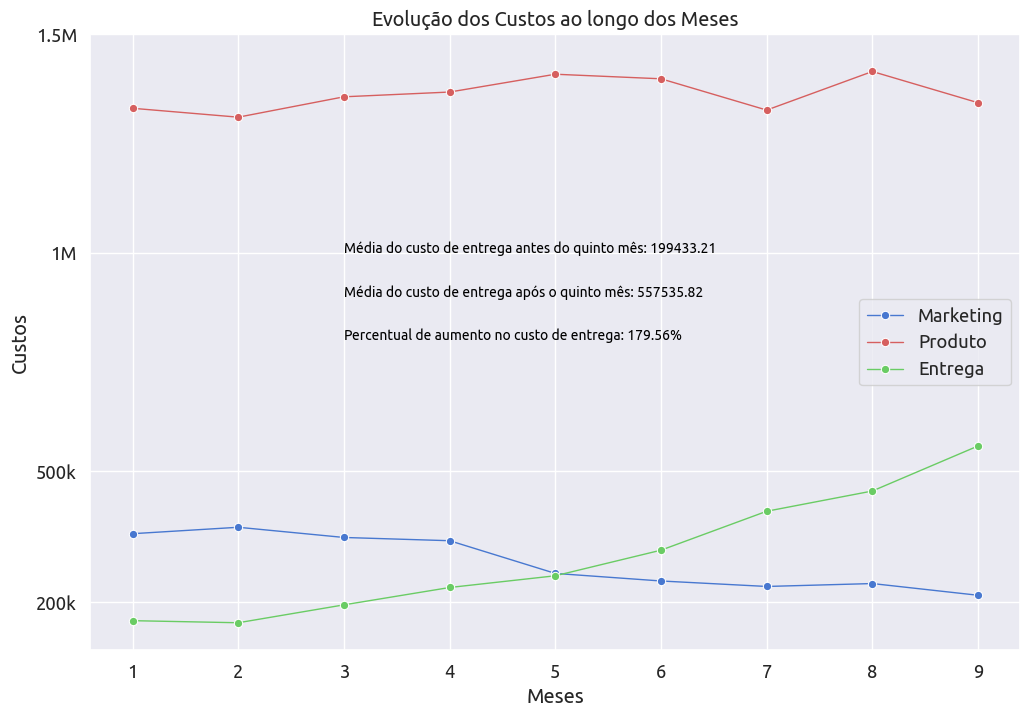

In [47]:
#Análise da progressão do custo ao decorrer do tempo

dados_antes = df_case[df_case['Mês'] <= 5]
dados_depois = df_case[df_case['Mês'] >= 9]

# Calculando a média do custo de entrega antes e depois do quinto mês
media_antes = dados_antes['Custo Entrega'].mean().round(2)
media_depois = dados_depois['Custo Entrega'].mean().round(2)

# Calculando o percentual de aumento
percentual_aumento = ((media_depois - media_antes) / media_antes) * 100
percentual_aumento = percentual_aumento.round(2)
sns.set_theme(style='dark', palette='muted', font='ubuntu', font_scale=1.2)


plt.figure(figsize=(12, 8))
sns.lineplot(x='Mês', y='Custo Marketing', data=df_case, errorbar=None, marker='o', label='Marketing', linewidth=1)
sns.lineplot(x='Mês', y='Custo dos Produtos', data=df_case, errorbar=None, marker='o', color='r', label='Produto', linewidth=1)
sns.lineplot(x='Mês', y='Custo Entrega', data=df_case, errorbar=None, marker='o', color='g', label='Entrega', linewidth=1)
plt.title('Evolução dos Custos ao longo dos Meses')
plt.xlabel('Meses')
plt.ylabel('Custos')

plt.yticks([200000, 500000, 1000000, 1500000], ['200k', '500k', '1M', '1.5M'])



plt.text(3, 1000000, f'Média do custo de entrega antes do quinto mês: {media_antes}', fontsize=10, color='black')
plt.text(3, 900000, f'Média do custo de entrega após o quinto mês: {media_depois}', fontsize=10, color='black')
plt.text(3, 800000, f'Percentual de aumento no custo de entrega: {percentual_aumento}%', fontsize=10, color='black')

# Adicionando uma linha vertical para indicar o fim do quinto mês
#plt.axvline(x=5, color='red', linestyle='--', label='Fim do Quinto Mês')

plt.grid(True)
plt.show()




### Conclusão:
Ao analisar o gráfico, fica claro que houve um aumento significativo no custo de entrega em comparação aos outros custos. O custo do produto permaneceu constante durante os nove meses, enquanto o custo de marketing por categoria diminuiu nesse período. Por outro lado, o custo de entrega seguiu uma tendência de aumento mês a mês, conforme ilustrado no gráfico.

Considerando que o volume de vendas se manteve estável, o aumento gradual no custo de entrega a partir do segundo mês impacta diretamente o lucro da empresa e, consequentemente, compromete a rentabilidade do XVendas.

O custo de entrega geralmente é composto por custos logísticos e pode ser explicado pelas seguintes variáveis:

1. **Preços dos combustíveis:** O aumento nos preços dos combustíveis afeta diretamente a cadeia logística do XVendas. Quanto maior o preço do combustível, maior o valor do frete para a entrega dos produtos.

2. **Mudanças nos custos trabalhistas:** Aumentos nos salários ou no pagamento de horas extras para as equipes logísticas durante períodos de pico ou devido à escassez de mão de obra aumentam os custos de entrega.

3. **Mudanças regulatórias:** Novas regulamentações ou impostos relacionados aos serviços de transporte e entrega também podem contribuir para o aumento desse custo.

4. **Distribuição geográfica:** Na tentativa de fomentar vendas em regiões geograficamente remotas, menos acessíveis ou distantes dos centros de distribuição e lojas, o custo de frete tende a aumentar devido à distância percorrida para a entrega. Exemplo: As regiões Norte e Nordeste correspondem, somadas, a mais de 63% do território brasileiro, tornando a gestão dos custos de entrega nessas regiões um grande desafio.

## Próximos passos

Na base de dados temos a coluna Categoria, vamos verificar se todos os segmentos de produtos sofreram incremento do **custo de entrega** de forma igual. 

In [24]:
contagem_categorias = df_case['Categoria'].value_counts().reset_index()
contagem_categorias.columns = ['Categoria', 'Contagem']
contagem_categorias.describe()

,Contagem
count,415.000000
mean,8.484337
std,1.560107
min,1.000000
25%,9.000000
50%,9.000000
75%,9.000000
max,9.000000


In [27]:
df_categoria_custo_entrega = df_case.groupby(['Categoria', 'Mês'])['Custo Entrega'].mean().reset_index()
df_categoria_custo_entrega.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3735 entries, 0 to 3734
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Categoria      3735 non-null   category
 1   Mês            3735 non-null   int64   
 2   Custo Entrega  3521 non-null   float64 
dtypes: category(1), float64(1), int64(1)
memory usage: 85.2 KB


/tmp/ipykernel_4614/4173420714.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_categoria_custo_entrega = df_case.groupby(['Categoria', 'Mês'])['Custo Entrega'].mean().reset_index()


In [41]:
df_case['Custo dos Produtos'].max().round(2)

np.float64(417080788.94)